In [10]:
import xclim
import xclim.indicators.atmos as atmos
import xclim.indicators.land as land
import xclim.testing as open_dataset
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
atmos.dryness_index?

Signature:      
atmos.dryness_index(
    pr: xarray.core.dataarray.DataArray | str = 'pr',
    evspsblpot: xarray.core.dataarray.DataArray | str = 'evspsblpot',
    lat: xarray.core.dataarray.DataArray | str | None = None,
    *,
    wo: 'Quantified' = '200 mm',
    freq: "Literal['YS', 'YS-JAN']" = 'YS',
    ds: xarray.core.dataset.Dataset | xarray.core.datatree.DataTree = None,
) -> xarray.core.dataarray.DataArray
Call signature:  atmos.dryness_index(*args, **kwds)
Type:            DRYNESS_INDEX
String form:     <xclim.indicators.atmos._precip.DRYNESS_INDEX object at 0x72d4ee686950>
File:            ~/.local/lib/python3.10/site-packages/xclim/indicators/atmos/_precip.py
Docstring:      
Dryness index (realm: atmos)

The dryness index is a characterization of the water component in winegrowing regions which considers the precipitation and evapotranspiration factors without deduction for surface runoff or drainage. Metric originally published in Riou et al. (1994).

This indicator wil

In [25]:
dir(atmos)

['__all__',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_conversion_all',
 '_deprecated_alias',
 '_name',
 '_obj',
 '_precip',
 '_precip_all',
 '_synoptic',
 '_synoptic_all',
 '_temperature',
 '_temperature_all',
 '_wind',
 '_wind_all',
 'annotations',
 'antecedent_precipitation_index',
 'australian_hardiness_zones',
 'biologically_effective_degree_days',
 'calm_days',
 'cffwis_indices',
 'chill_portions',
 'chill_units',
 'cold_and_dry_days',
 'cold_and_wet_days',
 'cold_spell_days',
 'cold_spell_duration_index',
 'cold_spell_frequency',
 'cold_spell_max_length',
 'cold_spell_total_length',
 'consecutive_frost_days',
 'convert',
 'cool_night_index',
 'cooling_degree_days',
 'cooling_degree_days_approximation',
 'corn_heat_units',
 'daily_freezethaw_cycles',
 'daily_pr_intensity',
 'daily_temperature_range',
 'daily_temperature_range_variability',
 'days_over_precip_doy_thresh',
 'days_over_precip_thre

In [18]:
lat, lon = 40.78, -73.97
#url = (    "https://archive-api.open-meteo.com/v1/archive"
#    f"?latitude={lat}&longitude={lon}"
#    "&start_date=1984-01-01&end_date=2025-12-31"
#    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum"
#    "&timezone=America/New_York"
#)
#df = pd.read_json(url)
#daily = pd.DataFrame(df['daily'].to_dict())
#daily['time'] = pd.to_datetime(daily['time'])
#daily = daily.set_index('time')
daily

,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum
time,,,,
1984-01-01,0.2,-7.5,-4.8,0.0
1984-01-02,2.2,-5.1,-2.0,0.3
1984-01-03,2.6,-5.5,-2.2,0.0
1984-01-04,4.9,-3.4,0.0,0.0
1984-01-05,6.4,-2.1,1.1,0.2
...,...,...,...,...
2025-12-27,-0.8,-7.5,-3.7,5.2
2025-12-28,0.9,-11.4,-5.8,0.9
2025-12-29,7.2,-1.3,3.3,3.8


In [19]:
def make_dataarray(series, units): 
    da = xr.DataArray(
        series.values, 
        dims = ['time'], 
        coords = {'time': series.index}, 
        attrs={'units':units}
    )
    return da

tasmax = make_dataarray(daily['temperature_2m_max'], 'degC')
tasmin = make_dataarray(daily['temperature_2m_min'], 'degC')
tas = make_dataarray(daily['temperature_2m_mean'], 'degC')
pr = make_dataarray(daily['precipitation_sum'], 'mm/day')

tas


<xarray.DataArray (time: 15341)> Size: 123kB
array([-4.8, -2. , -2.2, ...,  3.3, -1.3, -2.2])
Coordinates:
  * time     (time) datetime64[ns] 123kB 1984-01-01 1984-01-02 ... 2025-12-31
Attributes:
    units:    degC

In [ ]:
rx1day = atmos.max_1day_precipitation_amount(pr=pr, freq='YS')
tropical = atmos.tropical_nights(tasmin=tasmin, freq='YS')
TXx = atmos.tx_max(tasmax=tasmax, freq='YS')-273.15
heatwaves=atmos.heat_wave_frequency(tasmin=tasmin, tasmax=tasmax, 
                                    thresh_tasmin= '20 degC', 
                                    thresh_tasmax = '30 degC', 
                                    window=3,
                                    freq='YS')
TXx

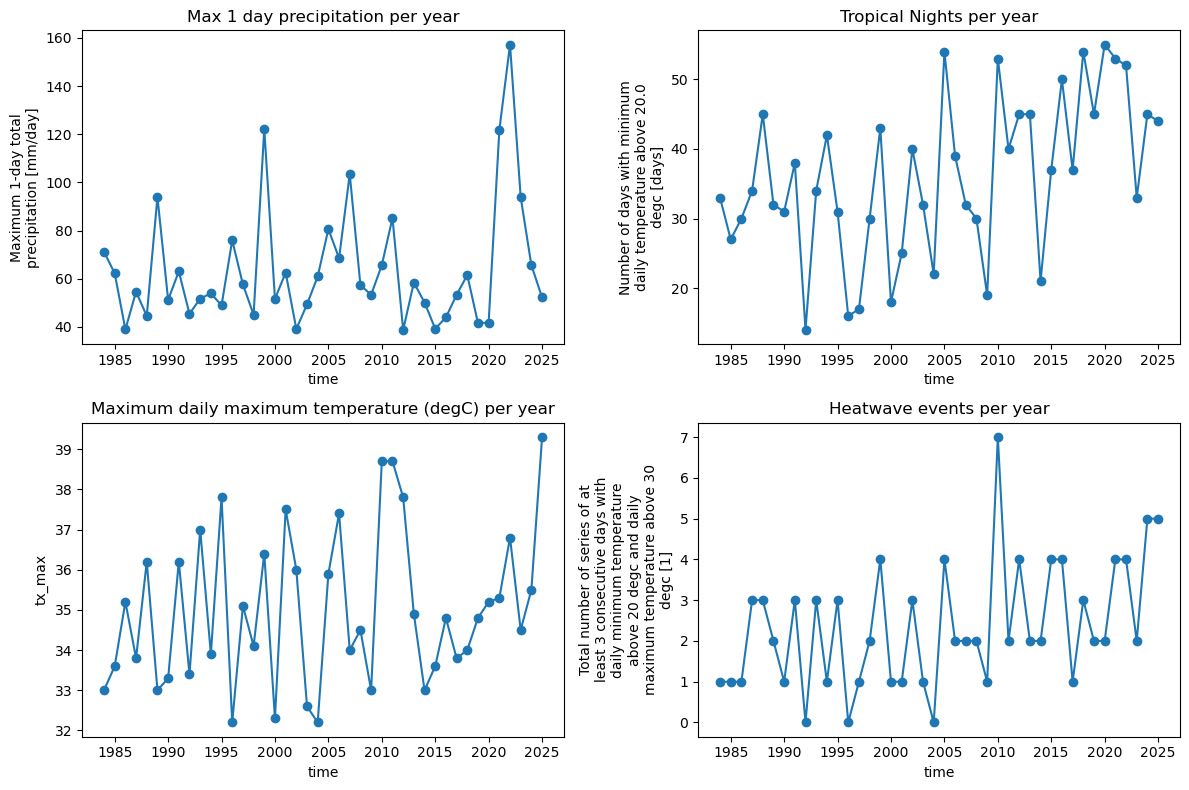

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
rx1day.plot(ax=axes[0,0], marker='o')
axes[0,0].set_title('Max 1 day precipitation per year')
tropical.plot(ax=axes[0,1], marker='o')
axes[0,1].set_title('Tropical Nights per year')
TXx.plot(ax=axes[1,0], marker='o')
axes[1,0].set_title('Maximum daily maximum temperature (degC) per year')
heatwaves.plot(ax=axes[1,1], marker='o')
axes[1,1].set_title('Heatwave events per year')
plt.tight_layout()